# 07｜Feature Engineering — Wafer-Level Process Features

## 這一本要做什麼？

06 已經看到，只用 Main Active Window 的平均值還不夠完整。有些 sensors 的 mean 幾乎不變，但其他 waveform 特徵還是可能有資訊。

所以 07 的任務很單純：

> **沿用 03 已經封版的同一個 Main Active Window，把 Raw 5 Hz process trace 轉成幾種容易理解、也能拿去做 Virtual Metrology 的 wafer-level features。**

這次每個 sensor 會建立 4 種 representation：

- `mean`
- `std`
- `robust_width = P90 - P10`
- `late_minus_early = 最後 20% 平均 - 前 20% 平均`

這一本不使用 Quality target 來挑 features。  
真正的 feature filtering、model selection 和 hyperparameter selection 都留到 08 的 grouped validation 裡做。


## 1. Feature Engineering 原則

我這裡刻意只做幾種很容易說明的 summary，不想一次塞太多複雜特徵。

| Feature Family | 怎麼算 | 我把它當成什麼 |
|---|---|---|
| `mean` | Main Active Window 平均值 | 整體 Process Level |
| `std` | Main Active Window 的 population std | Window 內的 signal spread |
| `robust_width` | P90 - P10 | 比較不容易被單一極端值影響的 spread |
| `late_minus_early` | 最後 20% mean - 前 20% mean | Window 前後段有沒有 level change |

另外再保留：

- `main_active_duration`：Main Active Process 持續多久

有幾個欄位我只拿來做 identity / validation，不當正式 predictor：

- `experiment_key`：ID
- `lot_number`：拿來做 grouped CV
- `wafer_number`：前面已經知道和 process、quality 都有 sequence 關係，直接放進模型可能讓模型只是在學順序
- `main_active_start` / `main_active_end`：會受到每片 raw recording 起點影響
- `main_active_samples`：和 duration 幾乎是同一件事
- `terminal_gap`：比較像資料記錄結構，不是我要建模的 process quantity

`late_minus_early` 的前後 20% 只是我這裡定義的 summary，不代表設備官方 step boundary。

另外，`std` 或 `robust_width` 比較大，也不能直接說製程比較不穩。Bosch etch 本來就有週期性的 signal behavior，所以這些數字可能同時混著正常 cycle structure 和其他變化。  
在 07，它們只是 predictors，不是 anomaly rules。


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from netCDF4 import Dataset

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_rows", 220)

def find_project_root(start=None):
    """Find the project root by walking upward from the current directory."""
    start = Path.cwd().resolve() if start is None else Path(start).resolve()

    for candidate in [start, *start.parents]:
        if (
            (candidate / "notebooks").exists()
            and (candidate / "data").exists()
        ):
            return candidate

    raise FileNotFoundError(
        "Project root not found. Expected a parent directory "
        "containing both notebooks/ and data/."
    )


CURRENT_DIR = Path.cwd().resolve()
PROJECT_ROOT = find_project_root(CURRENT_DIR)


RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
INTERIM_DATA_DIR = PROJECT_ROOT / "data" / "interim"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURE_DIR = PROJECT_ROOT / "reports" / "figures"

PROCESSED_DATA_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

process_path = RAW_DATA_DIR / "Process_data.nc"
dictionary_path = RAW_DATA_DIR / "Dictionary_process.nc"
usable_features_path = INTERIM_DATA_DIR / "usable_process_features.csv"
quality_summary_path = PROCESSED_DATA_DIR / "wafer_quality_summary.csv"
canonical_process_path = PROCESSED_DATA_DIR / "process_wafer_summary.csv"

required_paths = [
    process_path,
    dictionary_path,
    usable_features_path,
    quality_summary_path,
    canonical_process_path,
]

missing_paths = [
    path
    for path in required_paths
    if not path.exists()
]

if missing_paths:
    raise FileNotFoundError(
        "缺少必要輸入："
        + ", ".join(str(path) for path in missing_paths)
    )

for path in required_paths:
    print(f"{path.name:<38}", "存在")

print("NetCDF Backend： netCDF4")

Process_data.nc                        存在
Dictionary_process.nc                  存在
usable_process_features.csv            存在
wafer_quality_summary.csv              存在
process_wafer_summary.csv              存在
NetCDF Backend： netCDF4


### 1.1 路徑檢查結果

需要的 5 個輸入檔案都有找到：

- `Process_data.nc`
- `Dictionary_process.nc`
- `usable_process_features.csv`
- `wafer_quality_summary.csv`
- `process_wafer_summary.csv`

而且目前統一使用 `netCDF4` 讀取 Raw process file。07 不再保留第二套 NetCDF fallback，避免同一條 pipeline 因不同 backend 產生兩套讀檔邏輯；`netCDF4` 因此也是本專案的必要環境套件。

這一步最重要的不是「檔案都在」而已，而是資料責任分得很清楚：

- Raw trace 來自原始 NetCDF；
- usable sensors 沿用 01；
- Quality summary 沿用 02；
- Main Active Window 沿用 03。

所以 07 可以重新讀 Raw trace，但**不能重新決定 process window**。下一步會再確認 sensor 和 wafer 數量也和上游完全一致。

In [2]:
usable_process_features = (
    pd.read_csv(usable_features_path)["feature"].tolist()
)
wafer_quality = pd.read_csv(quality_summary_path)
canonical_process = pd.read_csv(canonical_process_path)

assert len(usable_process_features) == 27
assert len(wafer_quality) == 88
assert wafer_quality["experiment_key"].is_unique
assert len(canonical_process) == 96
assert canonical_process["experiment_key"].is_unique
assert canonical_process["group_name"].is_unique

for feature in usable_process_features:
    column = f"main_mean__{feature}"
    if column not in canonical_process.columns:
        raise ValueError(f"03 canonical summary 缺少：{column}")

print("Usable Process Features：", len(usable_process_features))
print("Canonical Process Wafers：", len(canonical_process))
print("Quality Wafers：", len(wafer_quality))
print("Quality Unique Keys：", wafer_quality["experiment_key"].nunique())
print("\n08 Primary Target：mean_si_etch")
print("CV / spatial variation columns：保留供未來 extension，不在 08 本版建模")

Usable Process Features： 27
Canonical Process Wafers： 96
Quality Wafers： 88
Quality Unique Keys： 88

08 Primary Target：mean_si_etch
CV / spatial variation columns：保留供未來 extension，不在 08 本版建模


### 1.2 上游資料數量有沒有對上？

結果是：

- Usable Process Features：**27**
- Canonical Process Wafers：**96**
- Quality Wafers：**88**
- Quality Unique Keys：**88**

這些數字和 01、02、03 一致，所以 07 沒有自己多刪 sensor，也沒有偷偷少掉 wafer。

這裡也先把 08 的主要 target 固定成 `mean_si_etch`。  
像 `cv_si_etch_pct` 這類 within-wafer variation 指標仍然保留在資料表中，但這一版不另外再建第二個 model，避免只有 88 個 labels 還同時把 model decision space 擴太大。


## 2. 重新讀 Raw Trace，但不重新切 Process Window

這一步使用 `netCDF4.Dataset` 讀取 Raw NetCDF；切 window 時完全使用 03 已經存下來的 canonical：

- `main_active_start`
- `main_active_end`
- `main_active_samples`

每片 wafer 都會：

1. 讀取 Raw trace；
2. 按 01 / 03 的 terminal-gap 規則取得主要連續區段；
3. 檢查 terminal-gap flag 跟 03 一不一致；
4. 用 03 的 start / end / sample count 切出 active window；
5. 後面再檢查重新算出的 `mean__sensor` 能不能重現 03 的 `main_mean__sensor`。

這樣可以確保 07 只是新增 feature representation，不是在背後又做一次 segmentation，也避免因為不同 NetCDF backend 造成額外差異。

In [3]:
def clean_feature_name(value):
    if isinstance(value, (bytes, np.bytes_)):
        return value.decode("utf-8")
    return str(value)


def short_feature_name(feature):
    return feature.replace("Stat3_Etch_MV_", "")


def load_decoder(path):
    # Dictionary_process.nc stores the numeric decoder used by Process_data.nc.
    with Dataset(path, "r") as ds:
        return np.asarray(ds["data"][:])


def list_process_groups(path):
    # Each NetCDF group corresponds to one wafer process trace.
    with Dataset(path, "r") as ds:
        return list(ds.groups.keys())


def load_group_arrays(
    path,
    group_name,
    requested_features,
    decoder,
):
    # Read only the 27 sensors approved by the upstream QC step.
    with Dataset(path, "r") as ds:
        group = ds.groups[group_name]

        feature_names = [
            clean_feature_name(value)
            for value in group["feature"][:]
        ]

        feature_index = {
            feature: index
            for index, feature in enumerate(feature_names)
        }

        missing_features = [
            feature
            for feature in requested_features
            if feature not in feature_index
        ]

        if missing_features:
            raise ValueError(
                f"{group_name} 缺少 Features：{missing_features}"
            )

        indices = [
            feature_index[feature]
            for feature in requested_features
        ]

        encoded_data = np.asarray(
            group["data"][:, indices]
        )

        times = np.asarray(
            group["times"][:],
            dtype=float,
        )

    return times, decoder[encoded_data]


def get_main_continuous_segment(
    times,
    data,
    gap_threshold=1.0,
):
    times = np.asarray(times, dtype=float)
    data = np.asarray(data)

    if len(times) != len(data):
        raise ValueError("times 與 process data 長度不一致")

    time_diff = np.diff(times)

    if len(time_diff) > 0 and np.any(time_diff <= 0):
        raise ValueError("Process time axis 不是 strictly increasing")

    large_gap_indices = np.where(
        time_diff > gap_threshold
    )[0]

    if len(large_gap_indices) > 0:
        if not (
            len(large_gap_indices) == 1
            and large_gap_indices[0] == len(time_diff) - 1
        ):
            raise ValueError(
                "偵測到非 terminal 的 >1 s gap，與 01/03 QC 不一致"
            )

        return times[:-1], data[:-1], True

    return times, data, False


def slice_canonical_active_window(
    process_df,
    start_time,
    end_time,
    expected_samples,
):
    elapsed = process_df[
        "elapsed_seconds"
    ].to_numpy(dtype=float)

    mask = (
        (elapsed >= float(start_time) - 1e-9)
        & (elapsed <= float(end_time) + 1e-9)
    )

    active_df = process_df.loc[
        mask
    ].copy()

    # If floating-point boundary comparison changes the row count,
    # fall back to the nearest stored start/end samples from Notebook 03.
    if len(active_df) != int(expected_samples):
        start_idx = int(
            np.argmin(
                np.abs(
                    elapsed - float(start_time)
                )
            )
        )

        end_idx = int(
            np.argmin(
                np.abs(
                    elapsed - float(end_time)
                )
            )
        )

        active_df = process_df.iloc[
            start_idx:end_idx + 1
        ].copy()

    if len(active_df) != int(expected_samples):
        raise ValueError(
            "Canonical active-window sample count 無法重現："
            f"expected={expected_samples}, "
            f"actual={len(active_df)}"
        )

    if not np.isclose(
        active_df["elapsed_seconds"].iloc[0],
        float(start_time),
        atol=1e-8,
        rtol=0,
    ):
        raise ValueError(
            "Canonical active-window start 無法重現"
        )

    if not np.isclose(
        active_df["elapsed_seconds"].iloc[-1],
        float(end_time),
        atol=1e-8,
        rtol=0,
    ):
        raise ValueError(
            "Canonical active-window end 無法重現"
        )

    return active_df


print("Raw Reader + Canonical Window Slicer 建立完成")

Raw Reader + Canonical Window Slicer 建立完成


### 2.1 這個 Cell 現在代表什麼？

目前只建立了 Raw reader、terminal-gap handler 和 canonical window slicer，**還沒有真的產生任何 engineered feature**。

我刻意把這一步拆開，是因為如果讀檔、切 window、算 features 全塞在同一段 code，之後出問題會很難知道到底是哪一層錯。

下一步先確認 Raw NetCDF 裡的 96 個 groups，和 03 canonical table 的 96 個 `group_name` 是不是完全一樣。


In [4]:
decoder = load_decoder(dictionary_path)
process_groups = list_process_groups(process_path)

raw_group_set = set(process_groups)
canonical_group_set = set(canonical_process["group_name"])

assert len(process_groups) == 96
assert raw_group_set == canonical_group_set

print("Raw Process Groups：", len(process_groups))
print("Canonical Process Groups：", len(canonical_group_set))
print("Group Identity 完全一致：", raw_group_set == canonical_group_set)

Raw Process Groups： 96
Canonical Process Groups： 96
Group Identity 完全一致： True


### 3.1 Raw Groups 和 Canonical Table 有沒有一一對上？

結果是：

- Raw Process Groups：**96**
- Canonical Process Groups：**96**
- Group Identity 完全一致：**True**

這不只是兩邊剛好都 96 而已，而是兩個 set 完全相同。

所以可以確定：

- 沒有 Raw wafer 漏掉；
- 沒有 canonical wafer 找不到 raw trace；
- 沒有多出來或命名不同的 group。

接下來每一片 wafer 都能用「自己在 03 裡面保存的 window」來做 feature extraction。

## 4. 在同一個 Canonical Window 裡建立 108 個 Signal Features

27 個 usable sensors × 4 種 summaries = **108 個 signal features**。

其中 `mean__*` 會特別拿去和 03 的 `main_mean__*` 一個一個比。如果對不上，就代表 07 的切片流程和 03 不一致，不能繼續往下。


In [5]:
process_feature_records = []

canonical_process = (
    canonical_process
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

for _, meta in canonical_process.iterrows():
    raw_times, decoded_data = load_group_arrays(
        process_path,
        meta["group_name"],
        usable_process_features,
        decoder,
    )

    main_times, main_data, had_terminal_gap = (
        get_main_continuous_segment(
            raw_times,
            decoded_data,
        )
    )

    if bool(had_terminal_gap) != bool(meta["terminal_gap"]):
        raise ValueError(
            f"{meta['experiment_key']} terminal-gap 與 03 不一致"
        )

    process_df = pd.DataFrame(
        main_data,
        columns=usable_process_features,
    )
    process_df["elapsed_seconds"] = (
        main_times - main_times[0]
    )

    active_df = slice_canonical_active_window(
        process_df,
        meta["main_active_start"],
        meta["main_active_end"],
        int(meta["main_active_samples"]),
    )

    record = {
        "experiment_key": meta["experiment_key"],
        "lot_number": int(meta["lot_number"]),
        "wafer_number": int(meta["wafer_number"]),
        "terminal_gap": bool(meta["terminal_gap"]),
        "main_active_start": float(meta["main_active_start"]),
        "main_active_end": float(meta["main_active_end"]),
        "main_active_duration": float(meta["main_active_duration"]),
        "main_active_samples": int(meta["main_active_samples"]),
    }

    edge_count = max(
        1,
        int(np.floor(len(active_df) * 0.20)),
    )

    for raw_feature in usable_process_features:
        values = active_df[raw_feature].to_numpy(dtype=float)
        short = short_feature_name(raw_feature)

        record[f"mean__{short}"] = float(np.mean(values))
        record[f"std__{short}"] = float(np.std(values, ddof=0))
        record[f"robust_width__{short}"] = float(
            np.quantile(values, 0.90)
            - np.quantile(values, 0.10)
        )
        record[f"late_minus_early__{short}"] = float(
            np.mean(values[-edge_count:])
            - np.mean(values[:edge_count])
        )

    process_feature_records.append(record)

process_features_all = (
    pd.DataFrame(process_feature_records)
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

engineered_signal_columns = [
    c for c in process_features_all.columns
    if "__" in c
]

assert len(process_features_all) == 96
assert process_features_all["experiment_key"].is_unique
assert len(engineered_signal_columns) == 108

canonical_lookup = (
    canonical_process
    .set_index("experiment_key")
)

max_mean_abs_diff = 0.0

for raw_feature in usable_process_features:
    short = short_feature_name(raw_feature)

    current = process_features_all[
        f"mean__{short}"
    ].to_numpy(dtype=float)

    expected = (
        process_features_all["experiment_key"]
        .map(
            canonical_lookup[
                f"main_mean__{raw_feature}"
            ]
        )
        .to_numpy(dtype=float)
    )

    max_mean_abs_diff = max(
        max_mean_abs_diff,
        float(np.max(np.abs(current - expected))),
    )

    if not np.allclose(
        current,
        expected,
        atol=1e-10,
        rtol=1e-10,
    ):
        raise ValueError(
            f"07 mean__{short} 與 03 canonical mean 不一致"
        )

print("Process Wafers：", len(process_features_all))
print("Unique Wafers：", process_features_all["experiment_key"].nunique())
print("Engineered Signal Features：", len(engineered_signal_columns))
print("Expected：", len(usable_process_features) * 4)
print("Terminal Gap Wafers：", int(process_features_all["terminal_gap"].sum()))
print(
    "Missing Engineered Values：",
    int(process_features_all[engineered_signal_columns].isna().sum().sum()),
)
print(
    "Infinite Engineered Values：",
    int(
        np.isinf(
            process_features_all[engineered_signal_columns]
            .to_numpy(dtype=float)
        ).sum()
    ),
)
print(
    "Max |07 mean - 03 canonical mean|：",
    max_mean_abs_diff,
)

print("\nMain Active Duration Summary：")
display(process_features_all["main_active_duration"].describe())

Process Wafers： 96
Unique Wafers： 96
Engineered Signal Features： 108
Expected： 108
Terminal Gap Wafers： 69
Missing Engineered Values： 0
Infinite Engineered Values： 0
Max |07 mean - 03 canonical mean|： 4.547473508864641e-13

Main Active Duration Summary：


count     96.000000
mean     597.542083
std        2.198244
min      591.800000
25%      597.100000
50%      598.000000
75%      598.000000
max      602.200000
Name: main_active_duration, dtype: float64

### 4.1 Feature extraction 的結果怎麼看？

這次成功建立：

- Process Wafers：**96**
- Unique Wafers：**96**
- Engineered Signal Features：**108 = 27 × 4**
- Terminal Gap Wafers：**69**
- Missing engineered values：**0**
- Infinite values：**0**

最關鍵的是：

`Max |07 mean - 03 canonical mean| = 4.55 × 10⁻¹³`

這個差距小到可以當作 floating-point rounding，所以可以確定：

> **07 的 `mean__sensor` 和 03 的 canonical Main-Window mean 是同一套 process window 算出來的。**

Main Active Duration 也和 03 一致：

- Mean：約 **597.54 s**
- Std：約 **2.20 s**
- Min：**591.8 s**
- Median：**598.0 s**
- Max：**602.2 s**

所以 07 真正新增的不是另一份 mean，而是每個 sensor 的：

- window 內 spread
- robust spread
- early-to-late level change

這些才是後面 08 要測試有沒有 predictive value 的新資訊。


## 5. 標記 Full-Data Near-Constant Features，但先不刪

有些 engineered representations 在 96 片 wafer 上幾乎不變，例如某個 sensor 的 robust width 可能每片都差不多。

這裡會用：

```python
np.allclose(values, values[0], rtol=1e-7, atol=1e-8)
```

做一個 **full-data diagnostic**。

但這一版我不會在 07 就把它們從 modeling candidate table 刪掉。

原因是 08 要模擬「完全沒看過的新 Lot」。如果我先看完 96 片 predictor distribution 再決定哪些欄位要刪，held-out Lot 其實已經間接參與 preprocessing。

所以分工是：

- 07：只標記哪些欄位在 full data 看起來 near-constant；
- 08：每個 training fold 自己重新判斷要不要刪。

這樣 validation 會比較乾淨。


In [6]:
feature_metadata_records = []
full_data_near_constant_features = []

family_description = {
    "mean": "Main Active Process level",
    "std": "Within-window signal spread",
    "robust_width": "P90 - P10 robust spread",
    "late_minus_early": "Last 20% mean - first 20% mean",
}

for column in engineered_signal_columns:
    family, sensor_short = column.split("__", 1)
    values = process_features_all[column].to_numpy(dtype=float)

    is_effectively_constant_full_data = bool(
        np.allclose(
            values,
            values[0],
            rtol=1e-7,
            atol=1e-8,
        )
    )

    if is_effectively_constant_full_data:
        full_data_near_constant_features.append(column)

    feature_metadata_records.append(
        {
            "engineered_feature": column,
            "feature_family": family,
            "sensor_short": sensor_short,
            "raw_sensor": f"Stat3_Etch_MV_{sensor_short}",
            "description": family_description[family],
            "is_effectively_constant_full_data_diagnostic": (
                is_effectively_constant_full_data
            ),
        }
    )

feature_metadata = pd.DataFrame(feature_metadata_records)

full_data_near_constant_df = feature_metadata.loc[
    feature_metadata["is_effectively_constant_full_data_diagnostic"]
].copy()

diagnostic_varying_engineered_features = feature_metadata.loc[
    ~feature_metadata["is_effectively_constant_full_data_diagnostic"],
    "engineered_feature",
].tolist()

family_summary = (
    feature_metadata
    .groupby("feature_family", as_index=False)
    .agg(
        n_all=("engineered_feature", "size"),
        n_near_constant_full_data=(
            "is_effectively_constant_full_data_diagnostic",
            "sum",
        ),
    )
)

family_summary["n_varying_full_data_diagnostic"] = (
    family_summary["n_all"]
    - family_summary["n_near_constant_full_data"]
)

# Timing predictor 也加入 metadata；它仍是候選欄位，
# 真正是否在 training fold 中 near-constant 交給 08 的 fold-local filter。
duration_metadata = pd.DataFrame(
    [
        {
            "engineered_feature": "main_active_duration",
            "feature_family": "timing",
            "sensor_short": "MainActiveWindow",
            "raw_sensor": "Derived from SourceRFLoadPower threshold window",
            "description": "Main Active Process duration (seconds)",
            "is_effectively_constant_full_data_diagnostic": False,
        }
    ]
)

feature_metadata = pd.concat(
    [feature_metadata, duration_metadata],
    ignore_index=True,
)

print("All Engineered Signal Features：", len(engineered_signal_columns))
print(
    "Full-Data Near-Constant Diagnostic Features：",
    len(full_data_near_constant_features),
)
print(
    "Full-Data Varying Diagnostic Features：",
    len(diagnostic_varying_engineered_features),
)

print("\nFull-Data Near-Constant Diagnostic Features：")
for feature in full_data_near_constant_features:
    print("-", feature)

print("\nFeature Family Diagnostic Summary：")
display(family_summary)


All Engineered Signal Features： 108
Full-Data Near-Constant Diagnostic Features： 11
Full-Data Varying Diagnostic Features： 97

Full-Data Near-Constant Diagnostic Features：
- mean__EpdIntensity
- std__EpdIntensity
- robust_width__EpdIntensity
- late_minus_early__EpdIntensity
- robust_width__Gas5Flow
- robust_width__SourceRF2PeakToPeak
- robust_width__SourceRF2TuningCapacitor
- mean__SourceRFTuningCapacitor
- std__SourceRFTuningCapacitor
- robust_width__SourceRFTuningCapacitor
- late_minus_early__SourceRFTuningCapacitor

Feature Family Diagnostic Summary：


,feature_family,n_all,n_near_constant_full_data,n_varying_full_data_diagnostic
0,late_minus_early,27,2,25
1,mean,27,2,25
2,robust_width,27,5,22
3,std,27,2,25


### 5.1 目前有哪些欄位在完整資料上幾乎不變？

108 個 signal features 裡，有 **11 個**被 full-data diagnostic 標成 near-constant，剩下 **97 個**有明顯 variation。

分 family 看：

- `mean`：27 個裡 25 個 varying
- `std`：27 個裡 25 個 varying
- `late_minus_early`：27 個裡 25 個 varying
- `robust_width`：27 個裡只有 22 個 varying

所以 `robust_width` 比其他 family 更常出現接近常數的情況。

不過這裡的 11 個欄位**只是被標記，沒有被提前刪掉**。真正是否移除，要看它們在 08 當下的 training fold 裡是不是仍然 near-constant。  
這樣 held-out Lot 才不會參與 feature filtering。


### 5.2 接下來這張圖要看什麼？

我把四種 feature families 各自原本的 27 個欄位，和 full-data diagnostic 下仍有 variation 的數量畫在一起。

這張圖只是看 representation 的 variation 結構，不是在比較 model performance。  
Bar 比較高不代表預測一定比較好。


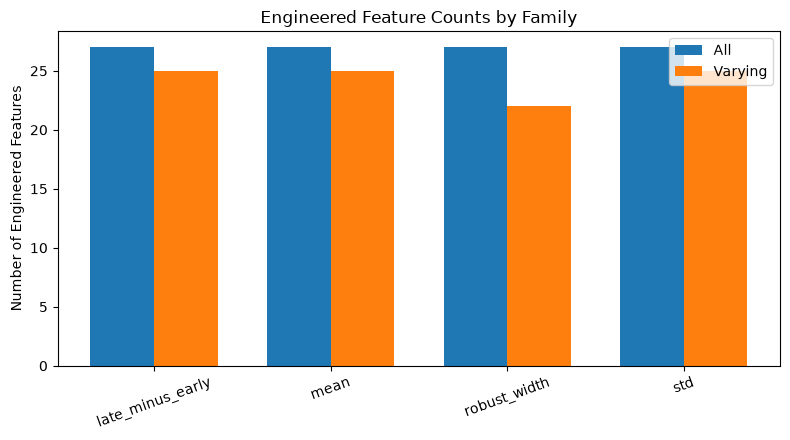

In [7]:
plt.figure(figsize=(8, 4.5))

x = np.arange(len(family_summary))

plt.bar(
    x - 0.18,
    family_summary["n_all"],
    width=0.36,
    label="All",
)

plt.bar(
    x + 0.18,
    family_summary["n_varying_full_data_diagnostic"],
    width=0.36,
    label="Varying",
)

plt.xticks(
    x,
    family_summary["feature_family"],
    rotation=20,
)

plt.ylabel("Number of Engineered Features")
plt.title("Engineered Feature Counts by Family")
plt.legend()
plt.tight_layout()
plt.show()


### 5.3 Bar chart 怎麼看？

四個 families 原本都是 27 個 features。

從圖上可以看出：

- `mean`、`std`、`late_minus_early` 都有 **25/27** 在完整資料上有 variation；
- `robust_width` 只有 **22/27**，所以比較常接近常數。

這和前面的表格完全一致。

我不會因為這張圖就說 robust width 沒用，因為它只是在描述「目前 96 片 wafer 的 variation」。  
08 還是會收到完整 candidate columns，然後在每個 training fold 裡自己決定哪些欄位要被 filter。


## 6. 建立 Base 和 Extended Candidate Predictor Sets

現在把 features 分成兩組，讓 08 可以比較「比較精簡」和「多加 robust width」有沒有差。

### Base Candidate Set

包含：

- `main_active_duration`
- 27 個 `mean`
- 27 個 `std`
- 27 個 `late_minus_early`

總共 **82 個 candidate predictors**。

### Extended Candidate Set

在 Base 上再加入：

- 27 個 `robust_width`

總共 **109 個 candidate predictors**。

這裡特別叫 **candidate**，因為某個欄位如果在某個 training fold 裡 near-constant，08 還會在 pipeline 裡把它拿掉。


In [8]:
# Candidate sets 只按 feature family 定義；不使用 96-row full-data mask刪欄位。
base_signal_features = [
    feature
    for feature in engineered_signal_columns
    if not feature.startswith("robust_width__")
]

extended_signal_features = engineered_signal_columns.copy()

base_predictor_columns = [
    "main_active_duration",
] + base_signal_features

extended_predictor_columns = [
    "main_active_duration",
] + extended_signal_features

feature_metadata["included_in_base"] = (
    feature_metadata["engineered_feature"].isin(base_predictor_columns)
)

feature_metadata["included_in_extended"] = (
    feature_metadata["engineered_feature"].isin(extended_predictor_columns)
)

assert len(base_signal_features) == 81
assert len(extended_signal_features) == 108
assert len(base_predictor_columns) == 82
assert len(extended_predictor_columns) == 109

print("Base Candidate Predictors：", len(base_predictor_columns))
print("  - Main Active Duration：1")
print("  - Signal Features：", len(base_signal_features))

print("\nExtended Candidate Predictors：", len(extended_predictor_columns))
print("  - Main Active Duration：1")
print("  - Signal Features：", len(extended_signal_features))

print("\n96 Process Wafers vs Candidate Predictor Count：")
print("Base：", len(process_features_all), "rows ×", len(base_predictor_columns), "predictors")
print("Extended：", len(process_features_all), "rows ×", len(extended_predictor_columns), "predictors")


Base Candidate Predictors： 82
  - Main Active Duration：1
  - Signal Features： 81

Extended Candidate Predictors： 109
  - Main Active Duration：1
  - Signal Features： 108

96 Process Wafers vs Candidate Predictor Count：
Base： 96 rows × 82 predictors
Extended： 96 rows × 109 predictors


### 6.1 兩個 Candidate Sets 最後有多大？

目前定義是：

- Base：**82 predictors**
- Extended：**109 predictors**

這兩個數字比舊版大，是因為我不再用 full-data near-constant mask 先刪那 11 個欄位。

所以 07 現在只負責定義 candidate space。真正進到模型的欄位數會是：

`Candidate columns → training-fold near-constant filter → StandardScaler → model`

這樣分工比較乾淨，也比較符合 held-out-Lot validation。


## 7. 看 Engineered Features 有沒有很嚴重的 Redundancy

同一個 sensor 被轉成 mean、std、robust width、late-minus-early 之後，本來就可能出現高度相關。

這裡只做 descriptive correlation diagnostic。  
為了避免 near-constant 欄位產生沒有意義的 correlation，這張表只用 full-data diagnostic 中有 variation 的 engineered features，加上 `main_active_duration`。

但這個 subset **只拿來看 correlation，不會拿去當 08 的最終 predictor mask**。


In [9]:
diagnostic_redundancy_columns = [
    "main_active_duration",
] + diagnostic_varying_engineered_features

extended_predictor_df = process_features_all[diagnostic_redundancy_columns].copy()

extended_corr = extended_predictor_df.corr(method="pearson")

correlation_pair_records = []

for i in range(len(diagnostic_redundancy_columns)):
    for j in range(i + 1, len(diagnostic_redundancy_columns)):
        r = float(extended_corr.iloc[i, j])

        correlation_pair_records.append(
            {
                "feature_1": diagnostic_redundancy_columns[i],
                "feature_2": diagnostic_redundancy_columns[j],
                "pearson_r": r,
                "abs_pearson_r": abs(r),
            }
        )

engineered_correlation_pairs = (
    pd.DataFrame(correlation_pair_records)
    .sort_values("abs_pearson_r", ascending=False)
    .reset_index(drop=True)
)

print("Extended Predictor Pairs：", len(engineered_correlation_pairs))
print(
    "|r| >= 0.95：",
    int((engineered_correlation_pairs["abs_pearson_r"] >= 0.95).sum()),
)

print("\nTop Correlated Engineered Predictor Pairs：")
display(engineered_correlation_pairs.head(15))


Extended Predictor Pairs： 4753
|r| >= 0.95： 29

Top Correlated Engineered Predictor Pairs：


,feature_1,feature_2,pearson_r,abs_pearson_r
0,mean__SourceRF2TuningCapacitor,late_minus_early__SourceRF2TuningCapacitor,-1.000000,1.000000
1,std__Gas1Flow,std__SourceRF2TuningCapacitor,0.999969,0.999969
2,mean__SourceRF2TuningCapacitor,std__SourceRF2TuningCapacitor,-0.998965,0.998965
3,std__SourceRF2TuningCapacitor,late_minus_early__SourceRF2TuningCapacitor,0.998959,0.998959
4,std__Gas1Flow,mean__SourceRF2TuningCapacitor,-0.998898,0.998898
5,std__Gas1Flow,late_minus_early__SourceRF2TuningCapacitor,0.998892,0.998892
6,mean__Heater1Temp,std__Heater1Temp,0.996696,0.996696
7,std__HeliumBPFlow,robust_width__HeliumBPFlow,0.996479,0.996479
8,mean__SourceRF2PeakToPeak,std__SourceRF2PeakToPeak,0.994057,0.994057
9,late_minus_early__Gas1Flow,mean__SourceRF2TuningCapacitor,0.993131,0.993131


### 7.1 高相關 pairs 怎麼看？

這個 diagnostic subset 一共有 **98 predictors**，所以共有：

`98 × 97 / 2 = 4,753` 組 pairs。

其中 `|r| >= 0.95` 有 **29 組**，比例其實不高，但最極端的幾組真的非常接近 ±1。

例如：

- `mean__SourceRF2TuningCapacitor` ↔ `late_minus_early__SourceRF2TuningCapacitor` = **-1.000**
- `std__Gas1Flow` ↔ `std__SourceRF2TuningCapacitor` ≈ **+0.99997**
- `mean__Heater1Temp` ↔ `std__Heater1Temp` ≈ **+0.99670**
- `std__HeliumBPFlow` ↔ `robust_width__HeliumBPFlow` ≈ **+0.99648**

所以某些 representations 幾乎是在描述同一個方向。

這件事對後面 modeling 很重要，因為如果直接用普通 OLS，coefficients 很容易因為共線性變得不穩。  
所以 08 會比較 ElasticNet、Ridge、PLS 這類比較適合高維相關 predictors 的方法。

我不在 07 直接把這 29 組全部刪掉，因為「高度相關」不代表其中一個一定對 unseen Lot 沒幫助。


### 7.2 再用 Histogram 看：高相關是少數，還是整體都很嚴重？

只看 top 15 pairs 可能會讓人覺得整個 feature matrix 都高度共線。

所以這張 histogram 把全部 **4,753 組 absolute correlations** 都畫出來，看看大部分 pair 實際落在哪裡。


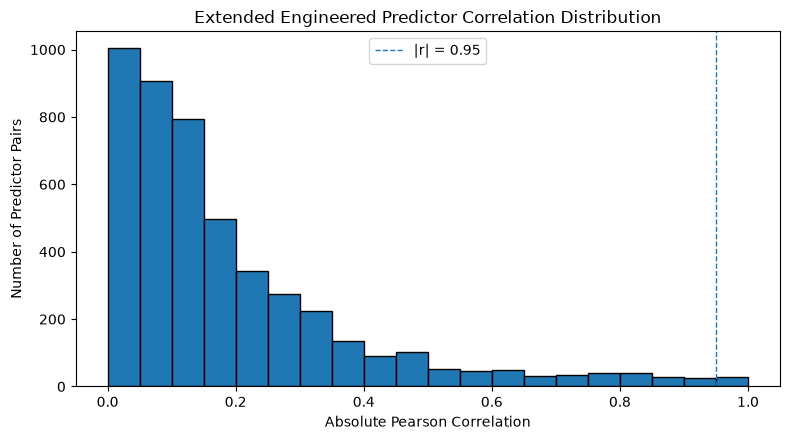

In [10]:
plt.figure(figsize=(8, 4.5))

plt.hist(
    engineered_correlation_pairs["abs_pearson_r"],
    bins=20,
    edgecolor="black",
)

plt.axvline(0.95, linestyle="--", linewidth=1, label="|r| = 0.95")

plt.xlabel("Absolute Pearson Correlation")
plt.ylabel("Number of Predictor Pairs")
plt.title("Extended Engineered Predictor Correlation Distribution")
plt.legend()
plt.tight_layout()
plt.show()


### 7.3 Histogram 怎麼看？

大部分 pairs 都集中在低到中等相關，尤其 **0～0.2** 的區間最多；correlation 越高，pair 數快速變少。

`|r| >= 0.95` 的 29 組只佔：

**29 / 4,753 ≈ 0.61%**

所以比較準確的說法不是「109 個 features 幾乎都重複」，而是：

> **大部分 features 還是保留不同資訊，但有少數局部組合存在非常強的 collinearity。**

這正好支持後面用 regularized / latent-variable models，而不是直接用 unregularized OLS。


## 8. 把 Process Features 和 Quality 一對一合併

Feature Engineering 本身不拿 target 來挑欄位，但 08 最後還是需要一張 Process + Quality 的 modeling table。

Merge 時同時用：

- `experiment_key`
- `lot_number`
- `wafer_number`

不是只靠一個 ID，這樣可以多確認一次 Lot 和 wafer number 沒有錯位。

這一步也會把 96 片 process wafers 和 88 片有 metrology 的 wafers 對一下，看看 supervised modeling 到底能用幾片。


In [11]:
metadata_columns = [
    "experiment_key",
    "lot_number",
    "wafer_number",
]

quality_target_columns = [
    "mean_si_etch",
    "cv_si_etch_pct",
    "std_si_etch",
    "range_si_etch",
    "p90_width_si_etch",
]

process_keys = set(process_features_all["experiment_key"])
quality_keys = set(wafer_quality["experiment_key"])

process_only_keys = sorted(process_keys - quality_keys)
quality_only_keys = sorted(quality_keys - process_keys)

modeling_dataset_base = (
    process_features_all[
        metadata_columns + base_predictor_columns
    ]
    .merge(
        wafer_quality[
            metadata_columns + quality_target_columns
        ],
        on=metadata_columns,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

modeling_dataset_extended = (
    process_features_all[
        metadata_columns + extended_predictor_columns
    ]
    .merge(
        wafer_quality[
            metadata_columns + quality_target_columns
        ],
        on=metadata_columns,
        how="inner",
        validate="one_to_one",
    )
    .sort_values(["lot_number", "wafer_number"])
    .reset_index(drop=True)
)

print("Process Wafers：", len(process_features_all))
print("Quality Wafers：", len(wafer_quality))
print("Matched Modeling Wafers：", len(modeling_dataset_extended))
print("Process-only Wafers：", len(process_only_keys))
print("Quality-only Wafers：", len(quality_only_keys))

print("\nBase Predictor Missing：", int(modeling_dataset_base[base_predictor_columns].isna().sum().sum()))
print("Extended Predictor Missing：", int(modeling_dataset_extended[extended_predictor_columns].isna().sum().sum()))
print("Target Missing：", int(modeling_dataset_extended[quality_target_columns].isna().sum().sum()))

print("\nProcess-only Keys：")
for key in process_only_keys:
    print("-", key)


Process Wafers： 96
Quality Wafers： 88
Matched Modeling Wafers： 88
Process-only Wafers： 8
Quality-only Wafers： 0

Base Predictor Missing： 0
Extended Predictor Missing： 0
Target Missing： 0

Process-only Keys：
- 2024-07-02_07
- 2024-08-21_09
- 2024-08-22_05
- 2024-08-22_06
- 2024-08-22_07
- 2024-08-22_08
- 2024-08-22_09
- 2024-08-22_10


### 8.1 Merge 後實際剩多少資料？

結果是：

- Process Wafers：**96**
- Quality Wafers：**88**
- 成功配對：**88**
- Process-only：**8**
- Quality-only：**0**
- Base / Extended predictor missing：**0**
- Target missing：**0**

所以 88 片有 Quality label 的 wafers 全部都成功找到 process features，07 沒有在 merge 這一步再掉樣本。

8 片 process-only wafers 沒有 metrology label，其中最後 6 片都來自同一個日期 / Lot。這也就是為什麼後面某個 Lot 只有 4 片 labeled wafers。

這件事對 08 很重要：不同 Lot 的樣本數不一樣，所以不能只報 pooled RMSE，還要看每個 held-out Lot 的 error。

另外，這 8 片沒有 label 的 wafers 仍然保留在 96-row process table 裡，之後 process-only anomaly / OOD 還可以用。


## 9. Modeling 前先做最基本的 Leakage Guard

進 08 之前，我先確認 predictor columns 沒有混進：

- ID
- Lot / wafer number
- Quality target
- terminal-gap metadata
- 04 的 target-derived ranking
- 05 的 retrospective SPC flags
- 06 的 full-data PCA scores

前面那些分析都很有用，但它們是 EDA / diagnostics，不應直接變成 08 的 predictors。

另外，07 的 full-data near-constant diagnostic 也不會拿來提前刪 model columns；真正的 filtering 還是留在 08 每個 training fold 裡面。


In [12]:
forbidden_predictor_columns = {
    "experiment_key",
    "lot_number",
    "wafer_number",
    "mean_si_etch",
    "cv_si_etch_pct",
    "std_si_etch",
    "range_si_etch",
    "p90_width_si_etch",
    "terminal_gap",
    "main_active_start",
    "main_active_end",
    "main_active_samples",
}

base_forbidden_overlap = sorted(
    set(base_predictor_columns) & forbidden_predictor_columns
)

extended_forbidden_overlap = sorted(
    set(extended_predictor_columns) & forbidden_predictor_columns
)

print("Base Forbidden Overlap：", base_forbidden_overlap)
print("Extended Forbidden Overlap：", extended_forbidden_overlap)

assert len(base_forbidden_overlap) == 0
assert len(extended_forbidden_overlap) == 0
assert modeling_dataset_extended["experiment_key"].is_unique
assert modeling_dataset_base["experiment_key"].is_unique

print("Column-Level Leakage Guard：通過")


Base Forbidden Overlap： []
Extended Forbidden Overlap： []
Column-Level Leakage Guard：通過


### 9.1 Leakage Guard 有沒有通過？

結果是：

- Base Forbidden Overlap：`[]`
- Extended Forbidden Overlap：`[]`
- `Column-Level Leakage Guard：通過`

所以目前的 predictor list 沒有直接把答案、group identity 或 wafer sequence 塞進去。

但這只能算第一層檢查。  
真正要避免 validation leakage，08 還必須把：

`Near-constant filter → scaling → model`

全部放在每個 training fold 裡重新 fit。  
如果 scaling 或 feature filtering 先看過 validation Lot，就算欄位名稱很乾淨，還是會洩漏。


## 10. 先看樣本數和 Predictor 數量，評估 08 的難度

目前：

- Process wafers：96
- Labeled wafers：88
- 做 outer CV 時，每次 training 還會再少掉一整個 Lot
- Base / Extended predictor 數都不算少

所以不能只看「總樣本 88」就覺得模型一定夠訓練。

尤其同一 Lot 裡的 wafers 很可能彼此比較像，所以 validation 一定要以 `lot_number` 分組，不能把同一 Lot 同時拆到 train 和 validation。


In [13]:
feature_set_summary = pd.DataFrame(
    [
        {
            "feature_set": "Base",
            "n_process_wafers": len(process_features_all),
            "n_labeled_wafers": len(modeling_dataset_base),
            "n_predictors": len(base_predictor_columns),
        },
        {
            "feature_set": "Extended",
            "n_process_wafers": len(process_features_all),
            "n_labeled_wafers": len(modeling_dataset_extended),
            "n_predictors": len(extended_predictor_columns),
        },
    ]
)

feature_set_summary["predictors_per_labeled_wafer"] = (
    feature_set_summary["n_predictors"]
    / feature_set_summary["n_labeled_wafers"]
)

display(feature_set_summary)

print("Labeled Wafers by Lot：")
display(
    modeling_dataset_extended
    .groupby("lot_number")
    .size()
    .rename("n_labeled_wafers")
    .reset_index()
)


,feature_set,n_process_wafers,n_labeled_wafers,n_predictors,predictors_per_labeled_wafer
0,Base,96,88,82,0.931818
1,Extended,96,88,109,1.238636


Labeled Wafers by Lot：


,lot_number,n_labeled_wafers
0,1,9
1,2,10
2,3,10
3,4,10
4,5,10
5,6,10
6,7,6
7,8,10
8,9,9
9,10,4


### 10.1 這是一個明顯的小樣本高維問題

目前：

- Base：**82 predictors / 88 labeled wafers**
- Extended：**109 / 88**

Extended 已經是 `p > n`，而且 outer fold 訓練時實際 `n` 還會更少。

各 Lot 的 labeled wafer 數也不平均：

- 多數 Lots 有 9～10 片
- Lot 7 只有 6 片
- Lot 10 只有 4 片

所以 08 不能只套一個複雜 model 看 training score，而是需要：

- Lot-grouped validation
- fold-local feature filtering / scaling
- regularization 或 latent-variable model
- per-Lot metrics
- pooled metric 和 fold-level result 一起看

07 的工作到這裡就夠了：把 candidate feature space 建乾淨，不在這一本先決定誰最好。


## 11. 把 Feature Engineering 結果存下來

最後把資料分成三類輸出：

**A. 96-row 完整 Process Feature Table**

保留所有 process wafers 和全部 108 個 signal features，方便之後追溯或做 process-only analysis。

**B. Modeling Candidate Tables**

- Base：不含 `robust_width`
- Extended：含 `robust_width`

另外各自再輸出和 Quality 成功配對的 88-row modeling dataset，直接給 08 使用。

**C. Metadata / Diagnostic Tables**

保留 feature family、raw sensor 對應、full-data near-constant flag 和高相關 pairs。

這樣後面不用再回 Raw NetCDF 重做一遍 feature engineering。


In [14]:
all_features_path = PROCESSED_DATA_DIR / "07_process_features_all.csv"
feature_metadata_path = PROCESSED_DATA_DIR / "07_engineered_feature_metadata.csv"
constant_features_path = PROCESSED_DATA_DIR / "07_full_data_near_constant_feature_diagnostic.csv"
correlation_pairs_path = PROCESSED_DATA_DIR / "07_engineered_high_correlation_pairs.csv"
feature_set_summary_path = PROCESSED_DATA_DIR / "07_feature_set_summary.csv"

process_base_path = PROCESSED_DATA_DIR / "07_process_features_base.csv"
process_extended_path = PROCESSED_DATA_DIR / "07_process_features_extended.csv"
modeling_base_path = PROCESSED_DATA_DIR / "07_modeling_dataset_base.csv"
modeling_extended_path = PROCESSED_DATA_DIR / "07_modeling_dataset_extended.csv"

process_features_all.to_csv(all_features_path, index=False)
feature_metadata.to_csv(feature_metadata_path, index=False)
full_data_near_constant_df.to_csv(constant_features_path, index=False)
engineered_correlation_pairs.loc[
    engineered_correlation_pairs["abs_pearson_r"] >= 0.95
].to_csv(correlation_pairs_path, index=False)
feature_set_summary.to_csv(feature_set_summary_path, index=False)

process_features_all[
    metadata_columns + base_predictor_columns
].to_csv(process_base_path, index=False)

process_features_all[
    metadata_columns + extended_predictor_columns
].to_csv(process_extended_path, index=False)

modeling_dataset_base.to_csv(modeling_base_path, index=False)
modeling_dataset_extended.to_csv(modeling_extended_path, index=False)

output_paths = [
    all_features_path,
    feature_metadata_path,
    constant_features_path,
    correlation_pairs_path,
    feature_set_summary_path,
    process_base_path,
    process_extended_path,
    modeling_base_path,
    modeling_extended_path,
]

for path in output_paths:
    if not path.exists():
        raise FileNotFoundError(f"輸出檔案不存在：{path}")

assert len(pd.read_csv(all_features_path)) == 96
assert len(pd.read_csv(process_base_path)) == 96
assert len(pd.read_csv(process_extended_path)) == 96
assert len(pd.read_csv(modeling_base_path)) == 88
assert len(pd.read_csv(modeling_extended_path)) == 88

print("所有 07 artifacts 已成功寫入並通過 row-count read-back validation")

所有 07 artifacts 已成功寫入並通過 row-count read-back validation


### 11.1 輸出檔案有沒有正確寫出？

9 個 CSV 都成功建立，而且重新讀回後 row count 都對：

- Full Process Features：**96 rows**
- Base Process Features：**96**
- Extended Process Features：**96**
- Base Modeling Dataset：**88**
- Extended Modeling Dataset：**88**

這個拆分很實用：

- **96-row tables** 保留沒有 Quality label 的 8 片 wafers，後面還能做 process anomaly / OOD；
- **88-row modeling tables** 只放 Process + Quality 都有的 wafers，直接交給 08。

所以 08 不需要重新讀 Raw trace，也不應自己再定義另一套 Base / Extended features。


# 07｜整份 Notebook 的統整結論

這一本主要解決的是：**怎麼把 03 已經確定好的 Main Active Process Window，轉成一張適合 08 做 Virtual Metrology 的 wafer-level feature table，而且不要在這一步先偷看 held-out Lot。**

首先，我重新讀 96 片 Raw process traces，但沒有重新找 window，而是完全沿用 03 保存的 start、end 和 sample count。最後重新算出的 `mean__sensor` 和 03 的 canonical mean 最大差只有 **4.55 × 10⁻¹³**，所以可以確定 07 沒有產生第二套 segmentation。

27 個 usable sensors 每個都建立 4 種 representations：

- mean
- std
- robust width
- late-minus-early

總共得到 **108 個 signal features**，另外再加 `main_active_duration`。

完整 96 片資料上，有 **11 個 features** 看起來 near-constant，其中 `robust_width` 比其他 family 更常出現這種情況。不過這些欄位只做 diagnostic，沒有在 07 直接刪除，因為真正的 near-constant filtering 要由 08 的每個 training fold 自己決定，避免 held-out Lot 參與 preprocessing。

最後建立的 candidate spaces 是：

- Base：**82 predictors**
- Extended：**109 predictors**

Correlation diagnostic 也顯示，高度相關的 pairs 確實存在，但 `|r| >= 0.95` 只有 **29 / 4,753 ≈ 0.61%**。也就是說，問題不是「全部 features 都重複」，而是有少數很強的 local collinearity，後面適合用 regularization / latent-variable methods 處理。

和 Quality merge 後，**88 片有 label 的 wafers 全部配對成功**，沒有再掉資料；剩下 8 片 process-only wafers 仍保留在完整 process table。

所以 07 最後真正交給 08 的不是「已經挑好的最佳 features」，而是一個**完整、可追溯、沒有先用 validation Lot distribution 做篩選的 candidate feature space**。

下一本 08 才會真正回答：

> **在每個 held-out Lot 完全不參與 near-constant filtering、scaling、model selection 和 hyperparameter selection 的情況下，這些 process features 到底能不能預測 unseen Lot 的 `mean_si_etch`？**
